In [1]:
# Import neccesary libraries.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import randint

# Current Approach in improving performance
 - Remove Outliers
 - Remove high dependent variables
 - Use regularization methods
 - Use deep neural networks
 - check assumption
 - Transform the response variable for stable distribution
 - Create more measures (utilities) from the data (e.g. Star Powers)

### Load data and check response distribution

In [2]:
df = pd.read_csv("data/movie_data_encoded.csv")
y = df['revenue']
columns_to_drop = ['Unnamed: 0', 'name', 'genres', 'directors', 'writers','actors', 'original_language', 'production_companies',
       'release_date','keywords', 'revenue']
X = df.drop(columns_to_drop, axis=1)
y_log = np.log1p(y)

In [3]:
def check_revenue_distribution(series):
    plt.figure(figsize=(8,5))
    sns.histplot(series, bins=50, kde=True)
    plt.title("Revenue Distribution")
    plt.show()

In [4]:
# In million
round(y.describe() / 1e6, 2)

count      0.01
mean      27.36
std       44.03
min        0.00
25%        2.30
50%       13.35
75%       34.95
max      908.01
Name: revenue, dtype: float64

In [5]:
#check_revenue_distribution(y)

In [6]:
#check_revenue_distribution(y_log)

### Transform Data and do train/test split

In [7]:
# Check VIF of each variable
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(len(X.columns))]

c:\Users\wue77\anaconda3\envs\movie_env\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\wue77\anaconda3\envs\movie_env\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [8]:
for i in vif[vif["VIF"] > 10]['feature']:
    X.drop(i, axis=1)

In [30]:
# Split original data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply log1p to y_train only
y_train_log = np.log1p(y_train)  # Train on log-transformed target

# Create polynomial features (For complex interaction)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

feature_names = poly.get_feature_names_out(X.columns)

# Scale features using training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)

### Dummy model performance

In [10]:
# Check the performance of the dummy variable
dummy_pred = np.full_like(y_test, y_train.mean())
RMSE = np.sqrt(mean_squared_error(y_test, dummy_pred))
R2 = r2_score(y_test, dummy_pred)

# Format RMSE (e.g., in millions)
print(f"RMSE: {round(RMSE / 1e6, 2)} Millions, R²: {round(R2, 2)}")

RMSE: 41.3 Millions, R²: -0.0


### Random Forest Regressor

In [10]:
RFR_tune = RandomForestRegressor()
param_dist = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [5, 10, 20, 30, None],
    'min_samples_split': [2, 5, 10],  # Prevents overfitting
    'min_samples_leaf': [1, 2, 4],  # Controls minimum samples per leaf
    'max_features': ['sqrt', 'log2', 0.5, None]  # Feature selection method
}

rand_search = RandomizedSearchCV(RFR_tune, param_distributions=param_dist, n_iter=10, cv=5, random_state=42, n_jobs=-1)

# Fit the random search object to the data.
rand_search.fit(X_train_poly_scaled, y_train_log.values.ravel())
rand_search.best_estimator_

RandomForestRegressor(max_depth=20, max_features=0.5, min_samples_leaf=4,
                      min_samples_split=5, n_estimators=500)

In [11]:
RFR = RandomForestRegressor(max_depth=20, max_features=0.5, min_samples_leaf=4, min_samples_split=5, n_estimators=500, oob_score=True, random_state=42)
RFR.fit(X_train_poly_scaled, y_train_log.values.ravel())
#y_pred = RFR.predict(X_test_poly_scaled)
y_pred = np.expm1(RFR.predict(X_test_poly_scaled))
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
R2 = r2_score(y_test, y_pred)
# Format RMSE (e.g., in millions)wwww
print(f"RMSE: {round(RMSE / 1e6, 2)} Millions, R²: {round(R2, 2)}")

RMSE: 29.04 Millions, R²: 0.51


In [18]:
RFR.oob_score_

0.9511394418030235

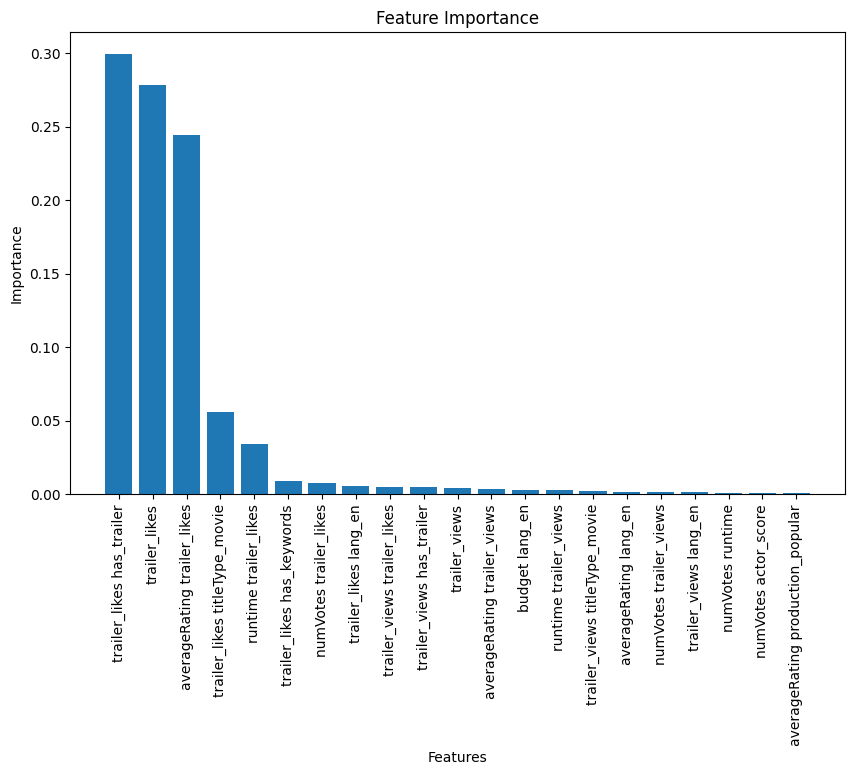

In [31]:
importances = RFR.feature_importances_

feature_importances = pd.DataFrame(RFR.feature_importances_, index=feature_names, columns=["importance"]).sort_values("importance", ascending=False)

# Select important features (importance >= 0.05)
important_features = feature_importances[feature_importances["importance"] >= 0.001].index

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.title("Feature Importance")

# Get corresponding importance values
important_importance_values = feature_importances.loc[important_features, "importance"]

# Plot
plt.bar(range(len(important_features)), important_importance_values, align="center")
plt.xticks(range(len(important_features)), important_features, rotation=90)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [32]:
# Select important features (importance >= 0.05)
important_features = feature_importances[feature_importances["importance"] >= 0.001].index

# Map feature names to column indices
important_feature_indices = [i for i, name in enumerate(feature_names) if name in important_features]

# Select only important features using integer indices
X_train_poly_scaled = X_train_poly_scaled[:, important_feature_indices]
X_test_poly_scaled = X_test_poly_scaled[:, important_feature_indices]

In [33]:
X_train_poly_scaled.shape

(9090, 21)

In [34]:
X_test_poly_scaled.shape

(2273, 21)

### Boosting Methods

In [35]:
GDB_tune = GradientBoostingRegressor()
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of boosting stages
    'learning_rate': [0.01, 0.1, 0.2],  # Step size shrinkage
    'max_depth': [3, 5, 7],  # Depth of each tree
    'min_samples_split': [2, 5, 10],  # Minimum samples to split an internal node
    'min_samples_leaf': [1, 2, 4],  # Minimum samples at a leaf node
    'subsample': [0.8, 1.0],  # Fraction of samples used for training each tree
    'max_features': ['sqrt', 'log2', None]  # Number of features per tree
}

rand_search = RandomizedSearchCV(GDB_tune, param_distributions=param_grid, cv=5, n_jobs=1)

# Fit the random search object to the data.
rand_search.fit(X_train_poly_scaled, y_train_log.values.ravel())
rand_search.best_estimator_

GradientBoostingRegressor(max_depth=5, max_features='sqrt', min_samples_leaf=2,
                          min_samples_split=10, n_estimators=200,
                          subsample=0.8)

In [40]:
GDB = GradientBoostingRegressor(max_depth=5, max_features='sqrt', min_samples_leaf=2, min_samples_split=10, n_estimators=200, subsample=0.8, random_state=42)
GDB.fit(X_train_poly_scaled, y_train_log.values.ravel())
#y_pred = GDB.predict(X_test_poly_scaled)
y_pred = np.expm1(GDB.predict(X_test_poly_scaled))
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
R2 = r2_score(y_test, y_pred)
# Format RMSE (e.g., in millions)wwww
print(f"RMSE: {round(RMSE / 1e6, 2)} Millions, R²: {round(R2, 2)}")

RMSE: 27.59 Millions, R²: 0.55
